# 火炎の位置を取得する
中心からr方向の火炎位置の分布を取得すること

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# img_path = '../image/ch_0kV.png'
# img_path = '../image/ch_10kV_nega.png'
img_path = '../image/ch_10kV_posi.png'

print(os.path.exists(img_path), img_path)

input_img = cv2.imread(img_path)
print(input_img.shape)

True ../image/ch_10kV_posi.png
(195, 367, 3)


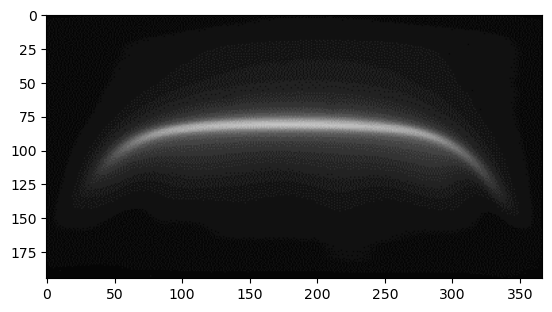

In [4]:
plt.imshow(input_img)

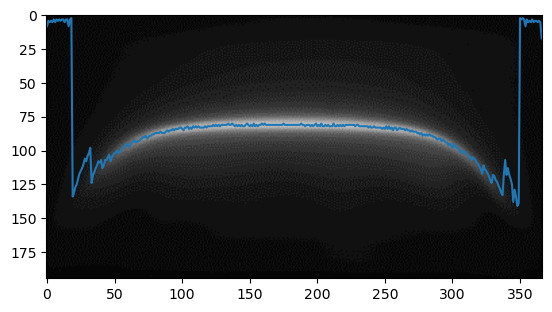

In [5]:
i_argmax = input_img.argmax(axis=0)[:, 0]

ax = plt.gca()

ax.imshow(input_img)
ax.plot(i_argmax)

ガウシアンフィルタをかけてみる

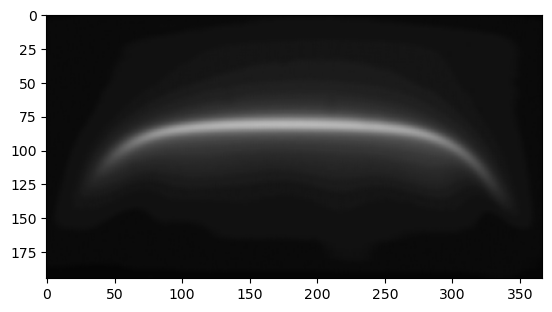

In [6]:
filtered_img = cv2.GaussianBlur(input_img, (5, 5), 4)
plt.imshow(filtered_img)

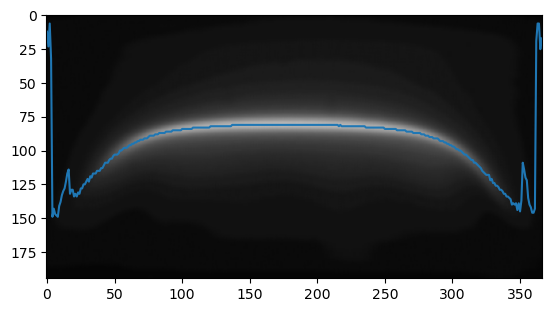

In [7]:
i_argmax = filtered_img.argmax(axis=0)[:, 0]

ax = plt.gca()

ax.imshow(filtered_img)
ax.plot(i_argmax)

## 最大強度をもとに火炎以外の領域を判定
最大強度の10%以下を無視する，とかでいい気がする  
最大強度の分布もFortranの計算に渡して，そこで領域を調整する

Text(0, 0.5, 'Normalized maximum intensity')

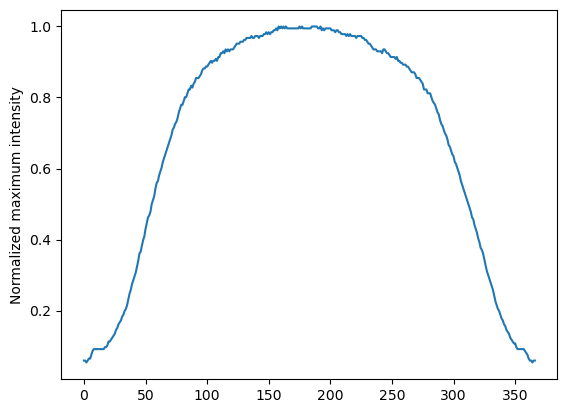

In [8]:
intensity_max = np.zeros(shape=i_argmax.shape)

for j, i in enumerate(i_argmax):
    intensity_max[j] = filtered_img[i, j, 0]

intensity_norm = intensity_max/intensity_max.max()

plt.plot(intensity_norm)
plt.ylabel('Normalized maximum intensity')

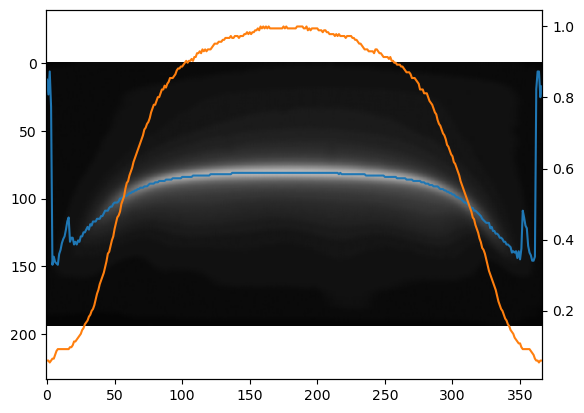

In [9]:
i_argmax = filtered_img.argmax(axis=0)[:, 0]

ax = plt.gca()

ax.imshow(filtered_img)
ax.plot(i_argmax)

ax2 = ax.twinx()
ax2.plot(intensity_norm, color='tab:orange')

<Axes: xlabel='index'>

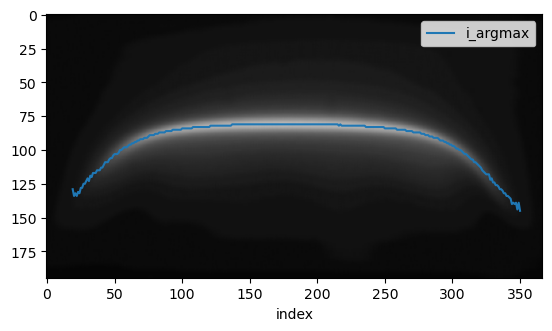

In [10]:
dict = {'index': np.arange(input_img.shape[1]),
    'i_argmax': i_argmax,
    'intensity_max': intensity_max,
    'intensity_norm': intensity_norm}
 
df = pd.DataFrame(dict)

ax = plt.gca()
ax.imshow(filtered_img)

threshold = 0.1
df.query(f'intensity_norm > {threshold}').plot(x='index', y='i_argmax', ax=ax)

# 計算に使用する領域を取得
中心からr方向の20 mm x 20 mmの正方形の領域

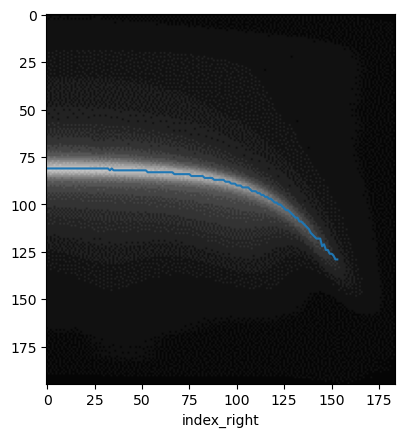

In [11]:
j_center = int((input_img.shape[1]-1)/2)

# plt.imshow(input_img[:, :j_center, :])

# plt.figure()

ax = plt.gca()
ax.imshow(input_img[:, j_center:, :])

threshold = 0.20
df['index_right'] = df['index'] - j_center
df.loc[j_center:, :].query(f'intensity_norm > {threshold}').plot(x='index_right', y='i_argmax', ax=ax)

ax.get_legend().remove()

# 20 mmで正規化

ギャップ長さで正規化したflame_heightを取得する

Text(0, 0.5, 'Normalized flame height [-]')

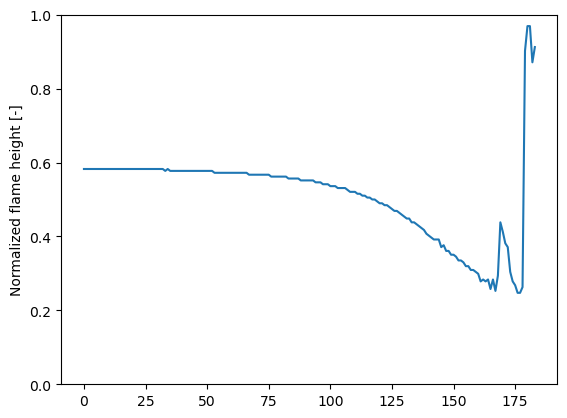

In [12]:
flame_height = (1.0 - i_argmax[j_center:].astype(np.float32)/(input_img.shape[0]-1))
plt.plot(flame_height)
plt.ylim(0.0, 1.0)
plt.ylabel('Normalized flame height [-]')

縦軸のスケールに合わせて横軸のindexを拡張する．  
現状だと195点で1になるように設定されている

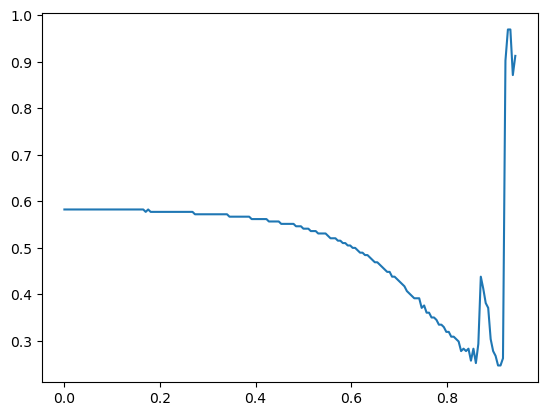

In [13]:
x = np.linspace(start=0.0, stop=1.0, num=input_img.shape[0])
x_trim = x[:flame_height.shape[0]]

plt.plot(x_trim, flame_height)

新しい座標系で補間する  
0-1を101分割したxで線形保管する  
分割数はfortranのnrと合わせる

In [14]:
nr = 401

x_new = np.linspace(start=0.0, stop=1.0, num=nr)
x_new

array([0.    , 0.0025, 0.005 , 0.0075, 0.01  , 0.0125, 0.015 , 0.0175,
       0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  , 0.0425, 0.045 , 0.0475, 0.05  , 0.0525, 0.055 , 0.0575,
       0.06  , 0.0625, 0.065 , 0.0675, 0.07  , 0.0725, 0.075 , 0.0775,
       0.08  , 0.0825, 0.085 , 0.0875, 0.09  , 0.0925, 0.095 , 0.0975,
       0.1   , 0.1025, 0.105 , 0.1075, 0.11  , 0.1125, 0.115 , 0.1175,
       0.12  , 0.1225, 0.125 , 0.1275, 0.13  , 0.1325, 0.135 , 0.1375,
       0.14  , 0.1425, 0.145 , 0.1475, 0.15  , 0.1525, 0.155 , 0.1575,
       0.16  , 0.1625, 0.165 , 0.1675, 0.17  , 0.1725, 0.175 , 0.1775,
       0.18  , 0.1825, 0.185 , 0.1875, 0.19  , 0.1925, 0.195 , 0.1975,
       0.2   , 0.2025, 0.205 , 0.2075, 0.21  , 0.2125, 0.215 , 0.2175,
       0.22  , 0.2225, 0.225 , 0.2275, 0.23  , 0.2325, 0.235 , 0.2375,
       0.24  , 0.2425, 0.245 , 0.2475, 0.25  , 0.2525, 0.255 , 0.2575,
       0.26  , 0.2625, 0.265 , 0.2675, 0.27  , 0.2725, 0.275 , 0.2775,
      

Text(0, 0.5, 'Interpolated flame height [-]')

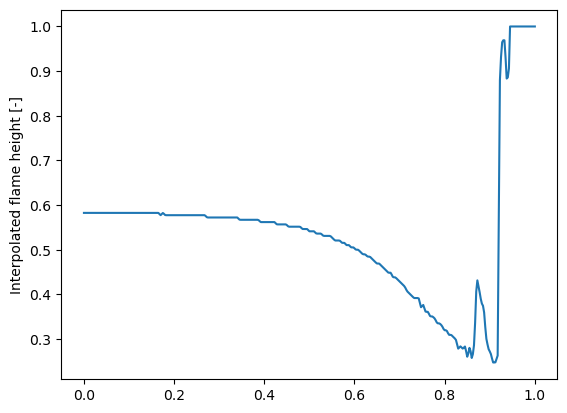

In [15]:
from scipy import interpolate

f = interpolate.interp1d(x_trim, flame_height, bounds_error=False, fill_value=1.0)
flame_height_new = f(x_new)

plt.plot(x_new, flame_height_new)
plt.ylabel('Interpolated flame height [-]')

intensityも同様に内挿する

In [22]:
intensity_norm

array([0.05913978, 0.05913978, 0.05376344, 0.05913978, 0.06451613,
       0.06451613, 0.07526882, 0.08602151, 0.09139785, 0.09139785,
       0.09139785, 0.09139785, 0.09139785, 0.09139785, 0.09139785,
       0.09139785, 0.09139785, 0.09677419, 0.09677419, 0.10215054,
       0.11290323, 0.11290323, 0.11827957, 0.12365591, 0.12903226,
       0.1344086 , 0.14516129, 0.15053763, 0.16129032, 0.16666667,
       0.17204301, 0.1827957 , 0.18817204, 0.19892473, 0.20430108,
       0.21505376, 0.2311828 , 0.24731183, 0.25806452, 0.27419355,
       0.28494624, 0.29569892, 0.30645161, 0.32258065, 0.33870968,
       0.36021505, 0.3655914 , 0.38172043, 0.39784946, 0.40860215,
       0.43010753, 0.44623656, 0.46236559, 0.46774194, 0.47849462,
       0.5       , 0.51075269, 0.52150538, 0.54301075, 0.55913978,
       0.56451613, 0.58064516, 0.59139785, 0.60215054, 0.61827957,
       0.62903226, 0.63978495, 0.65053763, 0.66129032, 0.67204301,
       0.6827957 , 0.69354839, 0.70967742, 0.71505376, 0.72580

Text(0, 0.5, 'Interpolated normalized intensity [-]')

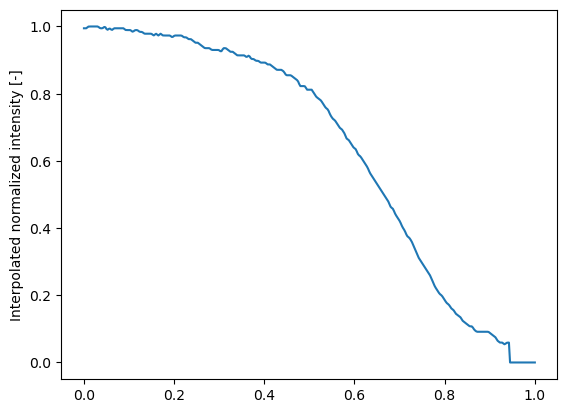

In [17]:
f = interpolate.interp1d(x_trim, intensity_norm[j_center:], bounds_error=False, fill_value=0.0)
intensity_norm_new = f(x_new)

plt.plot(x_new, intensity_norm_new)
plt.ylabel('Interpolated normalized intensity [-]')

# 近似曲線を作成する

(0.0, 1.0)

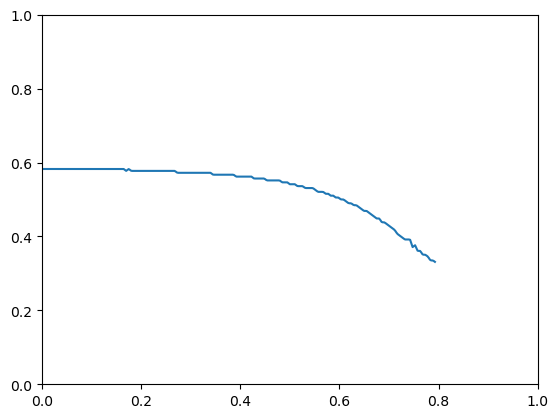

In [31]:
from scipy.optimize import curve_fit

flame_height_valid = flame_height_new[intensity_norm_new > 0.20]
x_new_valid = x_new[intensity_norm_new > 0.20]

ax = plt.gca()
ax.plot(x_new_valid, flame_height_valid)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

Fitted parameters: a=0.7374231420722506, b=7.633956202913434, c=0.8732123537123655, d=-0.15419558494232624
f(x) = 0.7374231420722506 / (1 + np.exp(7.633956202913434*(x-0.8732123537123655))) + -0.15419558494232624


/tmp/ipykernel_2729/1236923486.py:13: RuntimeWarning: overflow encountered in exp
  return a / (1 + np.exp(b*(x-c))) + d


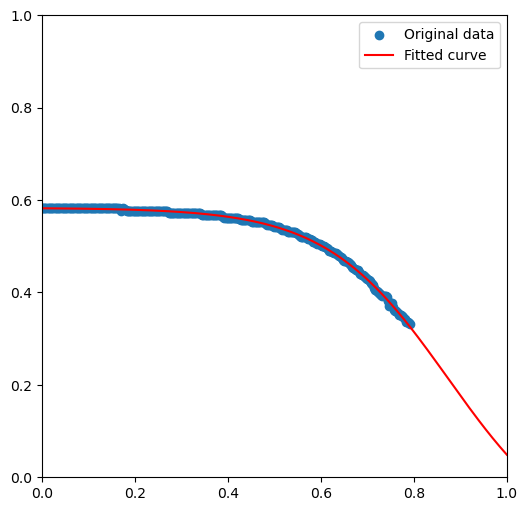

In [44]:
# import numpy as np
from scipy.optimize import curve_fit
# import matplotlib.pyplot as plt

y_data = flame_height_new[intensity_norm_new > 0.20]
x_data = x_new[intensity_norm_new > 0.20]

# フィッティング関数の定義（例：修正ガウス関数）
def modified_gaussian(x, a, b, c, d):
    # b=0 として中心を原点に固定（dy/dx=0 at x=0）
    # return a * np.exp(-(x)**2/c) + d    
    # return a - b*(x-c)**2 - d*(x-c)**4
    return a / (1 + np.exp(b*(x-c))) + d


# フィッティングの実行
params, covariance = curve_fit(modified_gaussian, x_data, y_data)

# フィッティング結果の表示
a, b, c, d = params
print(f"Fitted parameters: a={a}, b={b}, c={c}, d={d}")
print(f'f(x) = {a} / (1 + np.exp({b}*(x-{c}))) + {d}')

# フィッティング曲線の作成と外挿
x_extended = np.linspace(0, 1., 200)  # 外挿を含む範囲
y_fitted = modified_gaussian(x_extended, a, b, c, d)

plt.figure(figsize=(6, 6))
plt.scatter(x_data, y_data, label='Original data')
plt.plot(x_extended, y_fitted, 'r-', label='Fitted curve')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.legend()

# データを保存する
Fortranで読み込みやすいように，データ形式を指定してwriteしていく

In [18]:
path = '../input/flame_height_' + img_path.split('/')[-1].split('.')[0] + f'_nr{nr}'
path

'../input/flame_height_ch_10kV_posi_nr401'

In [19]:
# データ形式を指定して書き込む関数
def write_arrays_to_file(filename, arrays, format_str="%.8f"):
    # 配列を縦方向に結合し転置
    stacked_array = np.column_stack(arrays)
    
    # ファイルに書き込む
    np.savetxt(filename, stacked_array, fmt=format_str, delimiter=" ")
    print(f"Data written to {filename}")

# 使用例
write_arrays_to_file(path, [flame_height_new, intensity_norm_new])

Data written to ../input/flame_height_ch_10kV_posi_nr401
